In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [11]:
class State(TypedDict):
    ar : list[int]
    left_ar : list[int]
    right_ar : list[int]
    sorted_left : list[int]
    sorted_right : list[int]
    sorted_ar : list[int]

In [12]:
def split(St : State) -> State:
    ar = St['ar']
    n = len(ar)
    half_n = n // 2
    
    left_ar = ar[:half_n]
    right_ar = ar[half_n:]

    #St['left_ar'] = left_ar
    #St['right_ar'] = right_ar
    #return St

    return {
        'left_ar' : left_ar,
        'right_ar' : right_ar
    }

def left_sort(St: State) -> State:
    ar = St['left_ar']
    sorted_ar = sorted(ar)

    #St['sorted_left'] = sorted_ar
    #return St
    return {'sorted_left': sorted_ar}

def right_sort(St: State) -> State:
    ar = St['right_ar']
    sorted_ar = sorted(ar)

    St['sorted_right'] = sorted_ar
    return St
    #return {'sorted_right': sorted_ar}

def merge(St: State) -> State:
    sorted_left = St['sorted_left']
    sorted_right = St['sorted_right'] 

    ar = []
    i , j = 0, 0
    while i < len(sorted_left) or j < len(sorted_right):
        if i >= len(sorted_left) :
            ar.append(sorted_right[j])
            j += 1
            
        elif j >= len(sorted_right) :
            ar.append(sorted_left[i])
            i += 1
        
        elif sorted_left[i] < sorted_right[j]:
            ar.append(sorted_left[i])
            i += 1
        
        else:
            ar.append(sorted_right[j])
            j += 1
    
    #St['sorted_ar'] = ar
    #return St

    return {'sorted_ar': ar}

In [13]:
graph = StateGraph(State)

graph.add_node('SPLIT', split)
graph.add_node('LEFT_SORT', left_sort)
graph.add_node('RIGHT_SORT', right_sort)
graph.add_node('MERGE', merge)

graph.add_edge(START, 'SPLIT')
graph.add_edge('SPLIT', 'LEFT_SORT')
graph.add_edge('SPLIT', 'RIGHT_SORT')
graph.add_edge('LEFT_SORT', 'MERGE')
graph.add_edge('RIGHT_SORT', 'MERGE')
graph.add_edge('MERGE', END)

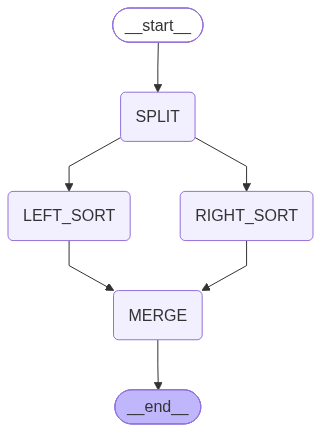

In [14]:
graph.compile()

In [15]:
agent = graph.compile()

In [16]:
intial_state = {'ar': [64,62,77,0]}
final_state = agent.invoke(intial_state)

In [17]:
print(final_state)

{'ar': [64, 62, 77, 0], 'left_ar': [64, 62], 'right_ar': [77, 0], 'sorted_left': [62, 64], 'sorted_right': [0, 77], 'sorted_ar': [0, 62, 64, 77]}


In [18]:
print(final_state['sorted_ar'])

[0, 62, 64, 77]
